Starting Training...


c:\Users\arung\anaconda3\envs\torch_clean\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0 | Loss: 1.9981e+00 | Nu^2: 0.752575
Epoch 1000 | Loss: 1.0428e-02 | Nu^2: 0.023486
Epoch 2000 | Loss: 3.5077e-03 | Nu^2: 0.007872
Epoch 3000 | Loss: 1.5271e-03 | Nu^2: 0.003499
Epoch 4000 | Loss: 7.4257e-04 | Nu^2: 0.002117
Epoch 5000 | Loss: 5.2125e-04 | Nu^2: 0.001727
Epoch 6000 | Loss: 3.7745e-04 | Nu^2: 0.001472
Epoch 7000 | Loss: 2.7672e-04 | Nu^2: 0.001284
Epoch 8000 | Loss: 2.7715e-04 | Nu^2: 0.001140
Epoch 9000 | Loss: 1.7162e-04 | Nu^2: 0.001048
Epoch 10000 | Loss: 1.4772e-04 | Nu^2: 0.000983


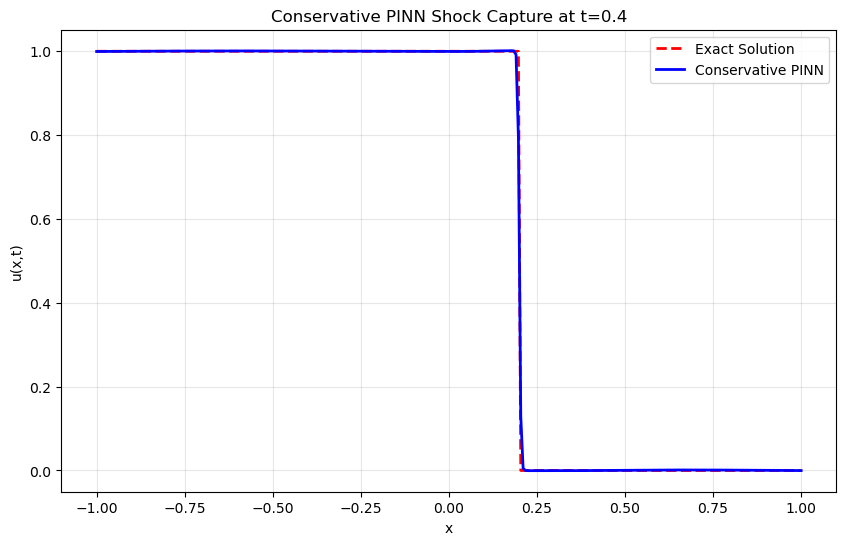

In [2]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from pyDOE import lhs

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. Physics & Exact Solution
# ==========================================
def exact_solution(x, t):
    """Exact inviscid shock solution: speed s = 0.5."""
    shock_pos = 0.5 * t
    return np.where(x < shock_pos, 1.0, 0.0)

# ==========================================
# 2. PINN Architecture
# ==========================================
class ConservativePINN(nn.Module):
    def __init__(self, u_layers, vis_layers, lb, ub):
        super().__init__()
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)
        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)

        # Velocity Network u(x, t)
        layers = []
        for i in range(len(u_layers) - 2):
            layers.append(nn.Linear(u_layers[i], u_layers[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(u_layers[-2], u_layers[-1]))
        self.u_net = nn.Sequential(*layers)

        # Viscosity Network ν(x, t)
        v_layers = []
        for i in range(len(vis_layers) - 2):
            v_layers.append(nn.Linear(vis_layers[i], vis_layers[i+1]))
            v_layers.append(nn.Tanh())
        v_layers.append(nn.Linear(vis_layers[-2], vis_layers[-1]))
        v_layers.append(nn.Softplus()) 
        self.vis_net = nn.Sequential(*v_layers)

    def forward(self, x):
        x_norm = 2.0 * (x - self.lb) / (self.ub - self.lb) - 1.0
        return self.u_net(x_norm)

    def get_viscosity(self, x):
        x_norm = 2.0 * (x - self.lb) / (self.ub - self.lb) - 1.0
        return self.vis_net(x_norm)

    def pde_residual(self, x_f):
        """
        Conservative PDE Residual: f = u_t + [0.5 * u^2]_x - nu^2 * u_xx
        """
        x_f.requires_grad_(True)
        u = self.forward(x_f)
        
        # flux F = 0.5 * u^2
        flux = 0.5 * u**2
        
        # Gradients
        grads_u = autograd.grad(u, x_f, torch.ones_like(u), create_graph=True)[0]
        u_x = grads_u[:, 0:1]
        u_t = grads_u[:, 1:2]
        
        grads_f = autograd.grad(flux, x_f, torch.ones_like(flux), create_graph=True)[0]
        flux_x = grads_f[:, 0:1]
        
        # Second derivative for diffusion
        u_xx = autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        
        nu = self.get_viscosity(x_f)
        f = u_t + flux_x - (nu**2) * u_xx
        return f, nu

# ==========================================
# 3. Training Function (Fixed)
# ==========================================
def train_model(model, lb, ub, epochs=10000):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # --- Data Generation ---
    # IC (t=0)
    x_ic = np.linspace(lb[0], ub[0], 200)[:, None]
    X_ic = torch.tensor(np.hstack([x_ic, np.zeros_like(x_ic)]), dtype=torch.float32).to(device)
    U_ic = torch.tensor(np.where(x_ic < 0, 1.0, 0.0), dtype=torch.float32).to(device)

    # BC (x=-1, x=1)
    t_bc = np.linspace(lb[1], ub[1], 100)[:, None]
    # Convert t_bc to tensor immediately to avoid the TypeError
    t_bc_tensor = torch.tensor(t_bc, dtype=torch.float32).to(device)
    
    X_bc_l = torch.tensor(np.hstack([-1*np.ones_like(t_bc), t_bc]), dtype=torch.float32).to(device)
    X_bc_r = torch.tensor(np.hstack([1*np.ones_like(t_bc), t_bc]), dtype=torch.float32).to(device)
    
    # FIXED: Using the tensor version for ones_like/zeros_like
    U_bc_l = torch.ones_like(t_bc_tensor)
    U_bc_r = torch.zeros_like(t_bc_tensor)

    # Collocation points
    X_f = torch.tensor(lb + (ub - lb) * lhs(2, 8000), dtype=torch.float32).to(device)

    print("Starting Training...")
    for i in range(epochs + 1):
        optimizer.zero_grad()
        
        # 1. IC Loss
        loss_ic = torch.mean((model(X_ic) - U_ic)**2)
        
        # 2. BC Loss
        loss_bc = torch.mean((model(X_bc_l) - U_bc_l)**2) + \
                  torch.mean((model(X_bc_r) - U_bc_r)**2)
        
        # 3. PDE and nu**2 -> 0 Loss
        f_res, nu = model.pde_residual(X_f)
        loss_f = torch.mean(f_res**2)
        loss_nu = torch.mean(nu**2)

        # Total Loss: Data + Physics + Regularization
        total_loss = loss_ic + loss_bc + loss_f + (0.1 * loss_nu)
        
        total_loss.backward()
        optimizer.step()
        
        if i % 1000 == 0:
            print(f"Epoch {i} | Loss: {total_loss.item():.4e} | Nu^2: {loss_nu.item():.6f}")

# ==========================================
# 4. Run and Plot
# ==========================================
lb, ub = np.array([-1.0, 0.0]), np.array([1.0, 0.5])
model = ConservativePINN([2, 20, 20, 20, 20, 1], [2, 10, 1], lb, ub).to(device)



train_model(model, lb, ub)

# Visualization
t_eval = 0.4
x_eval = np.linspace(-1, 1, 300)[:, None]
X_eval = torch.tensor(np.hstack([x_eval, np.ones_like(x_eval)*t_eval]), dtype=torch.float32).to(device)

u_pred = model(X_eval).cpu().detach().numpy()
u_exact = exact_solution(x_eval, t_eval)



plt.figure(figsize=(10, 6))
plt.plot(x_eval, u_exact, 'r--', label='Exact Solution', linewidth=2)
plt.plot(x_eval, u_pred, 'b-', label='Conservative PINN', linewidth=2)
plt.title(f"Conservative PINN Shock Capture at t={t_eval}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()